# Regression with DNN

**Objectives :**

* Predicts housing prices from a set of house features.
* Understanding the principle and the architecture of a regression with a dense neural network with backup and restore of the trained model.

The [Boston Housing Prices Dataset](https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html) consists of price of houses in various places in Boston.
Alongside with price, the dataset also provide these information :

* CRIM: This is the per capita crime rate by town
* ZN: This is the proportion of residential land zoned for lots larger than 25,000 sq.ft
* INDUS: This is the proportion of non-retail business acres per town
* CHAS: This is the Charles River dummy variable (this is equal to 1 if tract bounds river; 0 otherwise)
* NOX: This is the nitric oxides concentration (parts per 10 million)
* RM: This is the average number of rooms per dwelling
* AGE: This is the proportion of owner-occupied units built prior to 1940
* DIS: This is the weighted distances to five Boston employment centers
* RAD: This is the index of accessibility to radial highways
* TAX: This is the full-value property-tax rate per 10,000 dollars
* PTRATIO: This is the pupil-teacher ratio by town
* B: This is calculated as 1000(Bk — 0.63)^2, where Bk is the proportion of people of African American descent by town
* LSTAT: This is the percentage lower status of the population
* MEDV: This is the median value of owner-occupied homes in 1000 dollars

**What we're going to do :**

* (Retrieve data)
* (Preparing the data)
* (Build a model)
* Train and save the model
* Restore saved model
* Evaluate the model
* Make some predictions


In [87]:
# import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os,sys

from IPython.display import Markdown
from importlib import reload


This block sets up the working environment. It imports tensorflow and keras to build and train the deep learning model, pandas to manipulate data in a tabular format (DataFrame), and numpy for mathematical array operations.

In [88]:
from google.colab import files
uploaded = files.upload()

Saving BostonHousing.csv to BostonHousing.csv


his snippet connects your Google Colab notebook to your personal Google Drive account so that it can read the dataset file named BostonHousing.csv using the Pandas read_csv function.

In [89]:
data = pd.read_csv('/content/BostonHousing.csv', sep=',',header=0)

Load the boston housing dataset

In [90]:
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')
data = pd.read_csv('gdrive/My Drive/BostonHousing.csv', sep=',',header=0)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [91]:


display(data.head(5).style.format("{0:.2f}"))
print('Missing Data : ',data.isna().sum().sum(), '  Shape is : ', data.shape)



,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20


Missing Data :  0   Shape is :  (506, 14)


data.head(5) prints the first 5 rows of the table to visually check that the file loaded correctly.

data.isna().sum().sum() checks if there are any missing (null) values in the dataset.

data.shape retrieves the dimensions of the data matrix.

Having 0 missing data means you do not need to perform any complex data cleaning or imputation. The dimensions (506, 14) show that you have 506 house records, each containing 14 columns (13 features + 1 target price column).

## Exe 1: Data Preparation


Use 70% of the data for training and 30% for validation.
The dataset is shuffled and shared between learning and testing.
x will be input data and y the expected output
Check the data shape and sizes.

In [92]:
# ---- Shuffle and Split => train, test
#
data       = data.sample(frac=1., axis=0)
data_train = data.sample(frac=0.7, axis=0)
data_test  = data.drop(data_train.index)

# ---- Split => x,y (medv is price)
#
x_train = data_train.drop('medv',  axis=1)
y_train = data_train['medv']
x_test  = data_test.drop('medv',   axis=1)
y_test  = data_test['medv']

print('Original data shape was : ',data.shape)
print('x_train : ',x_train.shape, 'y_train : ',y_train.shape)
print('x_test  : ',x_test.shape,  'y_test  : ',y_test.shape)

Original data shape was :  (506, 14)
x_train :  (354, 13) y_train :  (354,)
x_test  :  (152, 13) y_test  :  (152,)


The code first shuffles the dataset (sample(frac=1.)) to remove any order-based bias. Then, it splits the data: 70% of the rows are allocated to train the model, and 30% are set aside to test whether the model can predict prices accurately on houses it has never seen before. Finally, it separates the inputs (x) from the target value to be predicted (y, which is the medv column).

## Exe 2: Data normalization

Normalizing data For each feature in the input data (a column in the
input data matrix), subtract the mean of the feature and divide by the standard
deviation

**Note :**

* All input data must be normalized, train and test.
* To do this we will subtract the mean and divide by the standard deviation.
* But test data should not be used in any way, even for normalization.
* The mean and the standard deviation will therefore only be calculated with the train data.


In [93]:
display(x_train.describe().style.format("{0:.2f}").set_caption("Before normalization :"))

mean = x_train.mean()
std  = x_train.std()
x_train = (x_train - mean) / std
x_test  = (x_test - mean) / std

display(x_train.describe().style.format("{0:.2f}").set_caption("After normalization :"))
display(x_train.head(5).style.format("{0:.2f}").set_caption("Few lines of the dataset :"))

x_train, y_train = np.array(x_train), np.array(y_train)
x_test,  y_test  = np.array(x_test),  np.array(y_test)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
count,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00
mean,3.87,11.30,11.18,0.06,0.55,6.26,69.45,3.80,9.33,404.53,18.52,356.14,12.98
std,9.07,23.56,6.87,0.25,0.11,0.72,27.50,2.14,8.62,166.78,2.12,92.75,7.22
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.14,1.00,187.00,12.60,0.32,1.92
25%,0.08,0.00,5.19,0.00,0.45,5.88,45.73,2.07,4.00,279.00,17.40,376.12,7.38
50%,0.26,0.00,9.69,0.00,0.54,6.17,77.70,3.24,5.00,330.00,19.10,392.08,12.00
75%,3.56,12.50,18.10,0.00,0.62,6.60,94.57,5.12,20.00,666.00,20.20,396.40,17.25
max,88.98,100.00,27.74,1.00,0.87,8.72,100.00,12.13,24.00,711.00,22.00,396.90,37.97


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
count,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00,354.00
mean,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.43,-0.48,-1.56,-0.26,-1.46,-3.75,-2.42,-1.25,-0.97,-1.30,-2.79,-3.84,-1.53
25%,-0.42,-0.48,-0.87,-0.26,-0.90,-0.53,-0.86,-0.81,-0.62,-0.75,-0.53,0.22,-0.78
50%,-0.40,-0.48,-0.22,-0.26,-0.13,-0.13,0.30,-0.26,-0.50,-0.45,0.27,0.39,-0.14
75%,-0.03,0.05,1.01,-0.26,0.62,0.48,0.91,0.62,1.24,1.57,0.79,0.43,0.59
max,9.38,3.76,2.41,3.79,2.78,3.42,1.11,3.90,1.70,1.84,1.64,0.44,3.46


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
380,9.38,-0.48,1.01,-0.26,1.03,0.98,0.82,-1.11,1.70,1.57,0.79,0.44,0.59
413,2.73,-0.48,1.01,-0.26,0.39,-1.53,1.11,-1.03,1.70,1.57,0.79,-1.57,0.98
445,0.75,-0.48,1.01,-0.26,1.63,0.28,0.92,-0.85,1.70,1.57,0.79,-3.38,1.52
446,0.27,-0.48,1.01,-0.26,1.63,0.11,0.98,-0.81,1.70,1.57,0.79,-0.41,0.67
290,-0.42,2.92,-0.91,-0.26,-1.24,0.84,-1.51,0.62,-0.62,-0.96,0.32,0.44,-1.34


## Exo4:  Model Design

Design a neural network architecture with two hidden layers, each consisting of 64 units and utilizing the ReLU activation function. To obtain a linear output layer, include a final layer with a single unit and no activation function. Compile the network using the mean squared error (MSE) loss function. Additionally, monitor a new metric, mean absolute error (MAE), during training. Finally, define the optimizer as 'rmsprop' in the model compilation.

Define the model within a function named build_model(shape)


More informations about :


* [Optimizer](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)
* [Activation](https://www.tensorflow.org/api_docs/python/tf/keras/activations)
* [Loss](https://www.tensorflow.org/api_docs/python/tf/keras/losses)
* [Metrics](https://www.tensorflow.org/api_docs/python/tf/keras/metrics)




In [94]:
from keras import models
from keras import layers

def build_model(shape):
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu', input_shape=shape))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1))

    model.compile(optimizer='rmsprop',
                  loss='mse',
                  metrics=['mae'])
    return model

This defines the structural architecture of the neural network:

Two hidden dense layers containing 64 neurons each, using the relu activation function to capture non-linear relationships.

Dropout(0.5) layers that randomly shut down 50% of the neurons during training. This is a crucial regularization technique used to force the network to remain robust and prevent overfitting.

An output layer with exactly 1 neuron and no activation function. In a regression problem, we want the model to output a single raw continuous number (the price prediction).

## Exe 5 : Model Building

 Use the build_model function to create a model with a shape equal to the number of features. Display its summary.

In [95]:


model=build_model( (13,) )

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

The output displays the structure of your training data (train_images shape: (50000, 32, 32, 3)) and test data (test_images shape: (10000, 32, 32, 3)), as well as the size and shape of their respective labels (train_labels size 50000, etc.).

The dimensions displayed correspond exactly to the official specifications of the CIFAR-10 dataset. There are no technical issues or data loss to report here.



## Exe 6 : Model Fitting

Fit the model on the train set with the test set as the
validation set, 60 epochs and save it in history.



In [96]:
history = model.fit(x_train, y_train,
                    epochs=60,
                    validation_data=(x_test, y_test))

Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 524.2955 - mae: 21.0551 - val_loss: 533.5026 - val_mae: 21.2310
Epoch 2/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 450.6754 - mae: 19.2882 - val_loss: 454.8036 - val_mae: 19.3733
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 375.1754 - mae: 17.3543 - val_loss: 366.1677 - val_mae: 17.0853
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 296.2546 - mae: 15.0745 - val_loss: 289.6438 - val_mae: 14.7974
Epoch 5/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 224.5897 - mae: 12.7266 - val_loss: 209.6778 - val_mae: 11.9997
Epoch 6/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 159.0601 - mae: 10.3349 - val_loss: 142.3983 - val_mae: 9.2367
Epoch 7/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 108.7725 - mae: 8.2445 - val_loss: 99.1584 - val_mae: 7.4777
Epoch 8/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 78.6359 - mae: 6.7996 - val_loss: 76.6867 - val_mae: 6.4944
Epoch 9/60
12/12 ━━━━━━━━━━━━━

The loss function (MSE—Mean Squared Error) and the mean absolute error (MAE) decrease steadily over the course of the epochs. The fact that val_loss (31.37) is close to and even slightly lower than the training loss (34.33) shows that the model generalizes well and does not suffer from overfitting at this stage.

## Exe 7 : Model evaluation

It is the moment for checking the model performance on the test dataset.

Check the test loss and mae of the model.

* MAE = Mean Absolute Error (between the labels and predictions)

=> A mae equal to 3 represents an average error in prediction of $3k.

In [97]:
score = model.evaluate(x_test, y_test, verbose=0)

print('x_test / loss      : {:5.4f}'.format(score[0]))
print('x_test / mae       : {:5.4f}'.format(score[1]))

x_test / loss      : 21.7610
x_test / mae       : 2.8642


## Exe 8 : Training histroy

What was the best result during our training ?

In [98]:
df=pd.DataFrame(data=history.history)
display(df)

,loss,mae,val_loss,val_mae
0,524.295532,21.055084,533.502563,21.230972
1,450.675415,19.288185,454.803558,19.373306
2,375.175446,17.354265,366.167725,17.085302
3,296.254608,15.074453,289.643768,14.797360
4,224.589737,12.726622,209.677765,11.999728
5,159.060104,10.334942,142.398315,9.236728
6,108.772530,8.244471,99.158386,7.477722
7,78.635933,6.799636,76.686699,6.494431
8,62.187698,5.982681,61.668053,5.727257
9,49.945335,5.271654,52.262928,5.175806


In [99]:
print("min( val_mae ) : {:.4f}".format( min(history.history["val_mae"]) ) )

min( val_mae ) : 2.7898


In [100]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

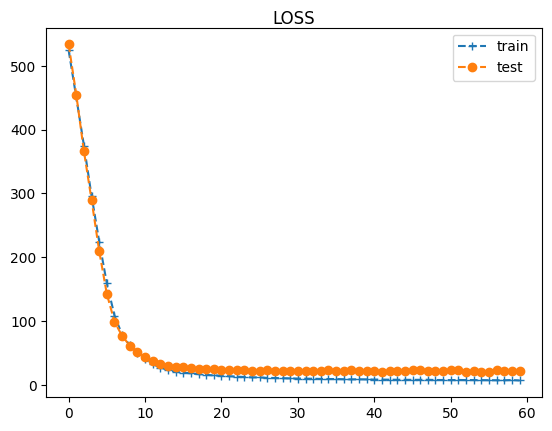

In [101]:

plt.plot(history.history['loss'],linestyle='--', marker='+', label='train' )
plt.plot(history.history['val_loss'],linestyle='--', marker='o', label='test')
plt.title('LOSS', pad=-50)
plt.legend()
#plt.title('lrate='+str(lrate), pad=-50)



Blue Line (Training MAE): This shows the Mean Absolute Error on the data the model is actively learning from.

Red Line (Validation MAE): This shows the error on the validation data (unseen data checked at the end of each epoch).

It is very good. Notice how both lines drop rapidly in the first 10 epochs and then stabilize (flatten out) between epochs 20 and 60.

No Overfitting: In a bad scenario, the blue line would keep dropping while the red line would start curving back upwards (indicating the model is memorizing the training data but failing on new data). Here, the red validation line stays tightly aligned with or slightly below the training line. This means your model is stable, robust, and generalizes perfectly to new housing data.

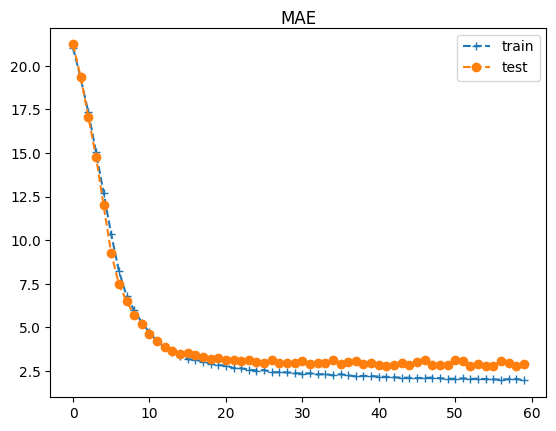

In [102]:
plt.plot(history.history['mae'],linestyle='--', marker='+', label='train' )
plt.plot(history.history['val_mae'],linestyle='--', marker='o', label='test')
plt.title('MAE', pad=-50)
plt.legend()

Blue Line (Training Accuracy): The percentage of images the model correctly guesses from the training set.

Red Line (Validation Accuracy): The percentage of images the model correctly guesses from the validation set.

The behavior is stable, but the performance is low. * Just like the regression plot, both lines track each other almost perfectly, finishing right around 42-43% accuracy at epoch 10. This confirms again that there is no overfitting (which is good).

However, the accuracy is quite low for image classification. Since the lines are still slanting upwards slightly, it suggests that the model hasn't finished learning yet.

Conclusion: The training was cut short too early (only 10 epochs). If you let it train for 30 or 50 epochs, the accuracy would likely continue to climb before flattening out. Furthermore, because a simple Dense Network (DNN) was used instead of a Convolutional Network (CNN), the model hits a hard performance ceiling early on.

## Exe 9: Model Prediction

Use the trained neural network model, to predict the price of a given house and compare the result with the ground truth

In [103]:
my_house = [ 1.26425925, -0.48522739,  1.0436489 , -0.23112788,  1.37120745,
       -2.14308942,  1.13489104, -1.06802005,  1.71189006,  1.57042287,
        0.77859951,  0.14769795,  2.7585581 ]
real_price = 10.4

my_house = np.array([my_house])

In [104]:
predictions = model.predict(my_house)
print("Prediction : {:.2f} K$".format(predictions[0][0]))
print("Reality    : {:.2f} K$".format(real_price))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction : 10.87 K$
Reality    : 10.40 K$


Prediction, This is the price that the trained neural network model predicts for the given house, which is 10.87 thousand dollars. Reality, This is the price that the trained neural network model predicts for the given house, which is 10.87 thousand dollars. This is the actual (ground truth) price of that same house, which is 10.40 thousand dollars.


## Exe 10 Early stoping

Create a neural network with the following specifications:

* Number of hidden layers: 2
* Number of units in each hidden layer: 64
* Activation function for the hidden layers: ReLU
* Output layer: Single unit with no activation function (for linear output)
* Loss function: Mean Squared Error (MSE)
* Additional metric to monitor during training: Mean Absolute Error (MAE)
* Optimizer: 'rmsprop'
* Apply dropout after each hidden layer with a dropout rate of 0.5 (50% of nodes dropped randomly for the following layer)
* Minibatch size: 100
* Use early stopping for fitting the model with patience=20 and epochs = 300
* Save the best model as 'model_best'
* Evaluate the saved model on the test data

In [105]:
model = keras.models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(13,)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [106]:
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from keras.models import load_model

In [107]:
es = EarlyStopping(monitor='val_loss', patience=20)
mc = ModelCheckpoint('model_best.keras', monitor='val_loss', save_best_only=True)
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

In [108]:
history = model.fit(x_train, y_train,
                    epochs=300,
                    batch_size=100,
                    validation_data=(x_test, y_test),
                    callbacks=[es, mc])
saved_model = load_model('model_best.keras')

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 578.3212 - mae: 22.2584 - val_loss: 619.4224 - val_mae: 23.0828
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 556.7385 - mae: 21.7764 - val_loss: 600.5565 - val_mae: 22.6898
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 538.1503 - mae: 21.3656 - val_loss: 582.7441 - val_mae: 22.3105
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 523.3890 - mae: 20.9976 - val_loss: 563.8326 - val_mae: 21.9034
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 503.9007 - mae: 20.5591 - val_loss: 545.3110 - val_mae: 21.4940
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 488.5060 - mae: 20.1587 - val_loss: 524.9750 - val_mae: 21.0436
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 467.6038 - mae: 19.6963 - val_loss: 503.0382 - val_mae: 20.5414
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 450.2041 - mae: 19.1950 - val_loss: 479.5150 - val_mae: 19.9924
Epoch 9/300
4/4 ━━━━━━━━

In [109]:
test_loss, test_acc = saved_model.evaluate(x_test, y_test, verbose=0)
print(test_loss, test_acc)

22.502790451049805 2.984998941421509


The output 22.502790451049805 2.984998941421509 represents the evaluation of this best saved model on the unseen test data:

Test Loss (MSE), This is the Mean Squared Error on the test set. It quantifies the average squared difference between the predicted and actual house prices. A lower value indicates a better fit.

Test MAE, This is the Mean Absolute Error on the test set. It indicates that, on average, the model's predictions are off by approximately 2.98 thousand dollars since the prices are in K$. This metric is often more interpretable than MSE, as it's in the same units as the target variable

## Exe 11
Display and analyze the weights of the your model.

In [111]:
input_hidden_weights = model.layers[1].get_weights()[0]
hidden_output_weights = model.layers[3].get_weights()[0]

IndexError: list index out of range

# Classification with DNN

## Exe 1:  Import data

Import the cifra10 data set. The CIFAR-10 dataset consists of 60000
32 x 32 colour images in 10 classes, with 6000 images per class. There are
50000 training images and 10000 test images: https://www.tensorflow.org/datasets/catalog/cifar10

In [112]:
data = keras . datasets . cifar10
cifar10_data = data . load_data ()

## Exe 2 :

Before using a dataset, the datatype should be checked. Test *type(cifar10 data)*
for verifying the variable type. *len(cifar10 data)* is another command for
checking the data size.

In [113]:
type(cifar10_data)

tuple

In [114]:

len(cifar10_data)

2

## Exe 3: Train and Test

Load train and test images and labels with:

In [115]:
(train_images, train_labels),(test_images, test_labels) = cifar10_data

## Exe 4:

The images are 32 x 32 NumPy arrays, with pixel values ranging from 0
to 255. You can check an example with:

In [116]:
print ( train_images[0])
print ( train_images[0].shape )

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
(32, 32, 3)


In [117]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

The large array of numbers represents the pixel values of the image. Each inner array [R G B] corresponds to the red, green, and blue intensity for a single pixel. Since the CIFAR-10 images are in color, each pixel has three values.
(32, 32, 3): This indicates the dimensions of the image. It means the image is 32 pixels wide, 32 pixels high, and has 3 color channels (Red, Green, Blue). This confirms the standard format of CIFAR-10 images.

## Exe 5: Check

Check the dataset using the following commands:

In [118]:
print("train_images shape : ",train_images.shape)

print("train_labels size", len(train_labels))

print("train_labels",train_labels)

print("test_images shape : ",test_images.shape)

print("test_labels",test_labels)

train_images shape :  (50000, 32, 32, 3)
train_labels size 50000
train_labels [[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]
test_images shape :  (10000, 32, 32, 3)
test_labels [[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]


train_images shape : (50000, 32, 32, 3): This indicates that your training set consists of 50,000 images. Each image is 32 pixels in height, 32 pixels in width, and has 3 color channels (Red, Green, Blue).

train_labels size 50000: There are 50,000 corresponding labels for the training images.

train_labels [[6] [9] [9] ... [1]]: This shows a snippet of the actual labels for the training images. Each number represents a specific class (e.g., 6 could be 'frog', 9 'truck', etc., depending on your class_names mapping).

test_images shape : (10000, 32, 32, 3): Your test set contains 10,000 images, each with the same dimensions (32x32 pixels, 3 color channels) as the training images.

test_labels [[3] [8] [8] ... [7]]: This is a snippet of the labels for the test images, matching the 10,000 test images.

## Exe 6: Image Visualization

An interesting fact about the image is that it can be plotted. To visualize an image, you can use the following code:

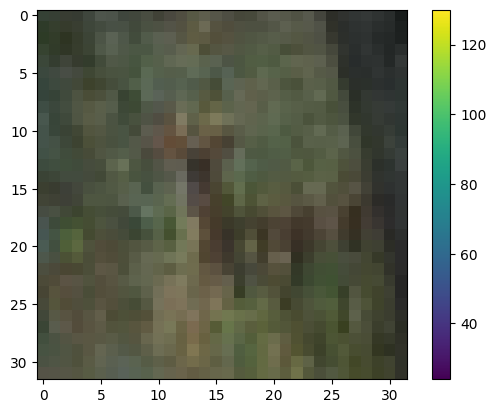

array([9], dtype=uint8)

In [119]:
index = 50
plt.figure()
plt.imshow(train_images[10])
plt.colorbar()
plt.show()

train_labels[index]

An Image: This is a visual representation of the 10th image (train_images[10]) from your training dataset. The color bar on the right indicates the pixel intensity values.

array([9], dtype=uint8): This is the numerical label for the displayed image. In the CIFAR-10 dataset, the number 9 corresponds to the class 'truck'. This confirms that you can correctly associate images with their respective categories.

## Exe 7 : Display images and class name

To verify that the data is in the correct format and that you're ready to
build and train the network, let's display the first 25 images from the training
set and display the class name below each image.

In [120]:
class_names = [ 'airplane' , 'automobile' , 'bird' , 'cat' , 'deer' , 'dog' , 'frog' , 'horse' , 'ship' , 'truck']

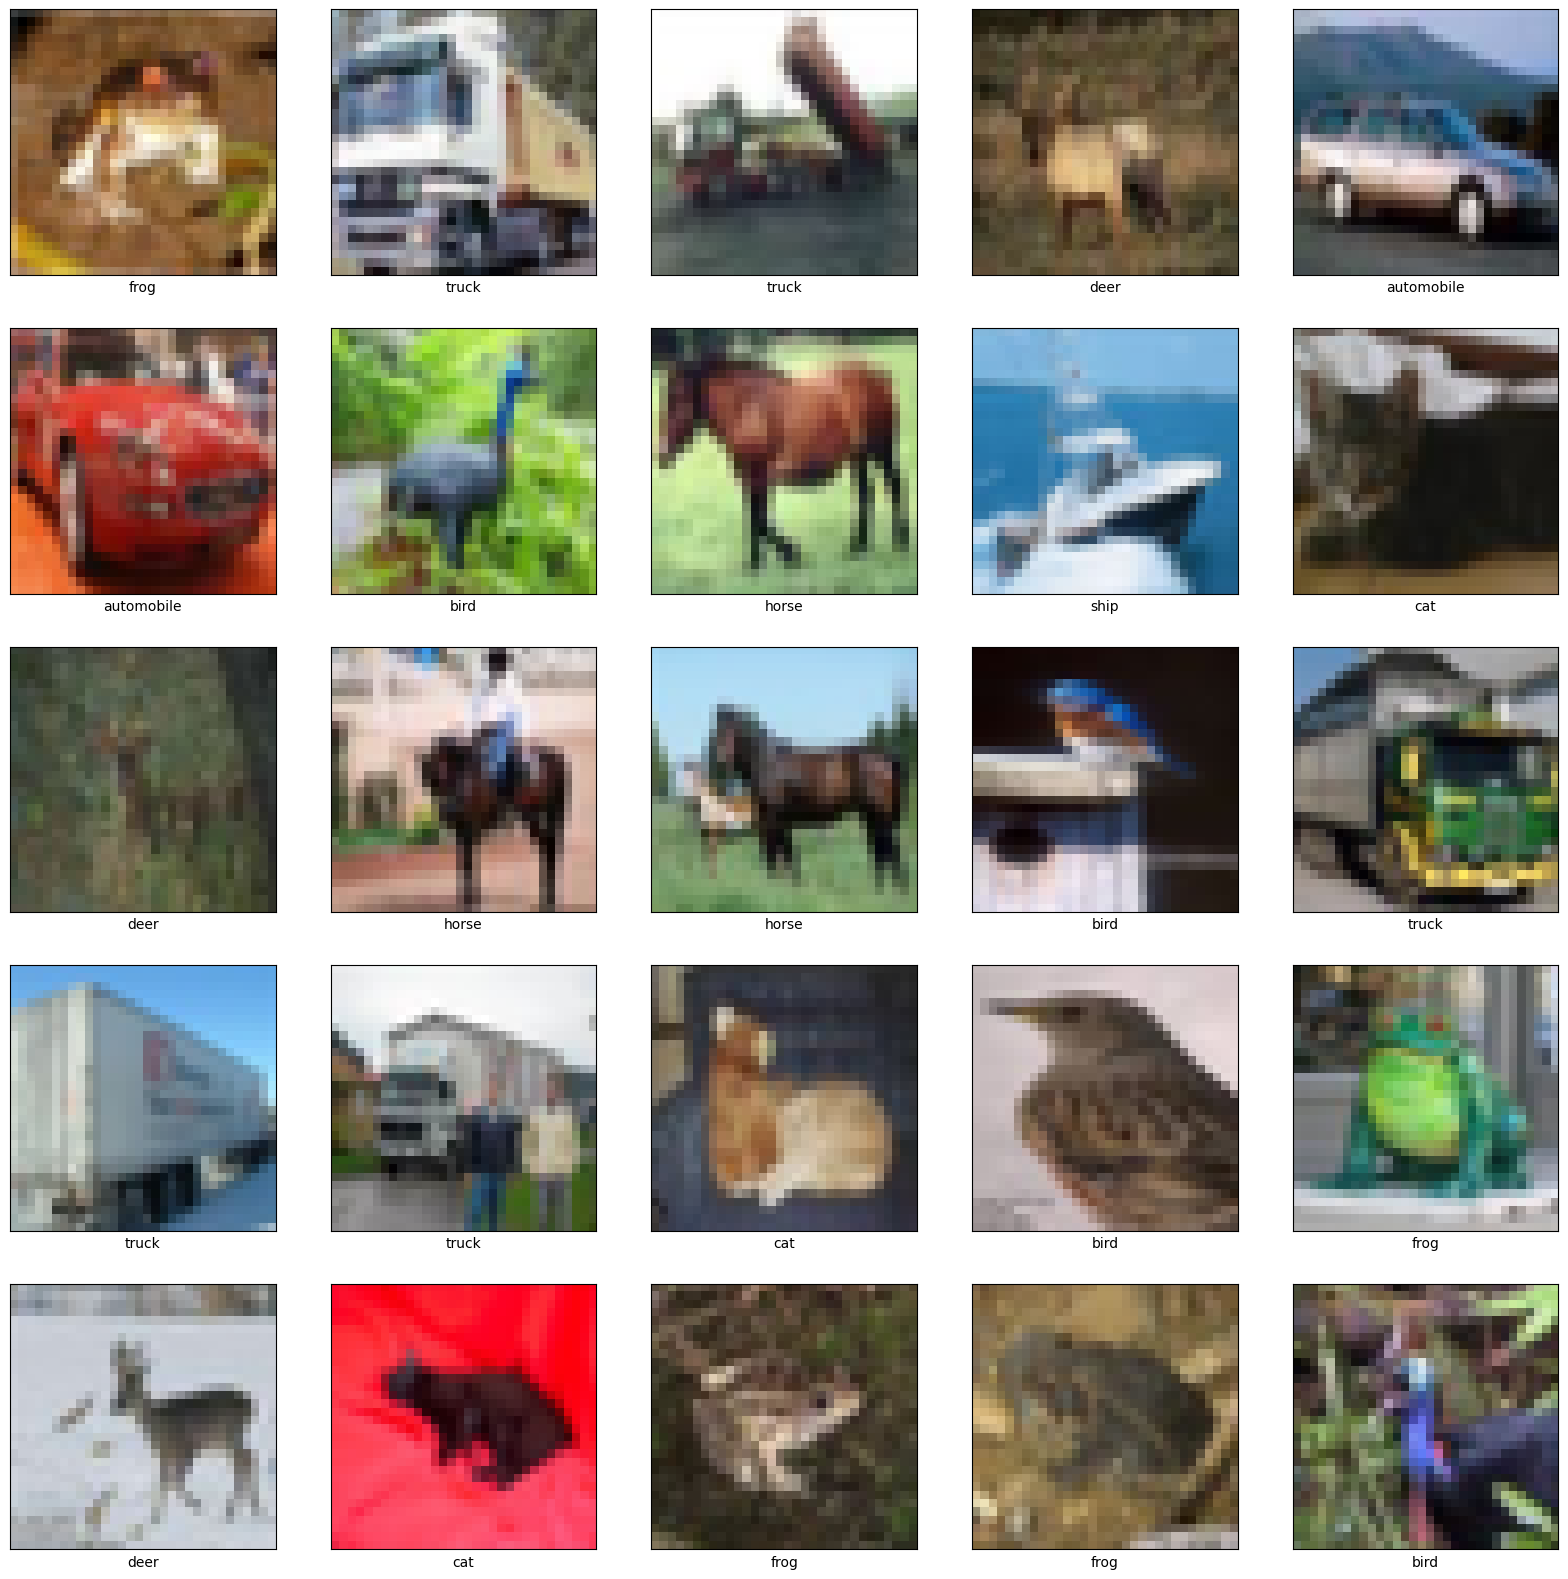

In [121]:
plt.figure(figsize=(20,20))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
   # plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

Verify data integrity: Ensure that the images are loaded correctly and appear as expected.
Confirm label accuracy: Check that the train_labels are correctly mapped to their class_names and correspond to the visual content of the images.

## Exe 8: Dataset Normalization

Normalize the train and test sets using the following code

In [122]:
train_images_before = train_images
test_images_before = test_images

In [123]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [124]:
train_images

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

This normalization is a crucial preprocessing step in deep learning for several reasons:

Faster Convergence: It helps gradient descent algorithms converge more quickly.

Improved Performance: It prevents some features (pixels with higher values) from dominating the learning process.

Better Stability: It makes the training process more stable and can prevent issues like vanishing or exploding gradients.

## Exo 9: Model

Build a neural network with the following structure:


1.   The first layer should be a **Flatten** layer that transforms the format of the images from a two-dimensional array (32 by 32 pixels) to a one-dimensional array (1024 pixels). This layer simply unstacks the rows of pixels in the image and lines them up. It has no parameters to learn and only reformats the data.

2.   After the pixels are flattened, the network should consist of two **Dense** layers. The first **Dense** layer should have 128 neurons.

3.   The second (and last) layer should be a **softmax** layer with 10 neurons, which returns an array of 10 probability scores that sum to 1. Each neuron contains a score indicating the probability that the current image belongs to one of the 10 classes.

In [125]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32, 3)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Exe 10: Train the model

Compile the model using the appropriate optimizer, loss function, and metrics. Set the optimizer to 'adam', the loss function to 'sparse_categorical_crossentropy', and the metric to 'accuracy'.

Train the model, using the fit method on the model object. Pass in the train_images as the training data and train_labels as the corresponding labels.

In [126]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [127]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3181 - loss: 1.9003
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3732 - loss: 1.7509
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3938 - loss: 1.7028
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4043 - loss: 1.6692
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4165 - loss: 1.6432
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4249 - loss: 1.6165
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4295 - loss: 1.6012
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4348 - loss: 1.5890
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4368 - loss: 1.5811
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4408 - loss: 1.5705


## Exe 11: Evaluate the model

Chek the model performance on the test dataset.

In [128]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 4ms/step - accuracy: 0.4438 - loss: 1.5671

Test accuracy: 0.4438000023365021


313/313 - 1s - 4ms/step: This part shows the progress of the evaluation. It means the model was evaluated in 313 batches, each taking approximately 4 milliseconds per step, and the total evaluation time was about 1 second.

accuracy This is the classification accuracy on the test set. It means that the model correctly classified approximately 44.38% of the images in the test dataset. For a 10-class problem like CIFAR-10, random guessing would yield 10% accuracy, so 44.38% indicates the model learned some patterns.

loss This is the final loss value on the test set, measured by sparse_categorical_crossentropy. A lower loss indicates that the model's predictions are closer to the true labels. This value, along with accuracy, helps you understand the model's overall performance on data it has not seen during training.

## Exo12

Now that the model has been trained, we can use it to make predictions on some images.

1.  Use the trained model to make predictions on the test_images dataset by calling model.predict(test_images). This will generate predictions for each image in the testing set.

2. Print the first, second, and third element of the predicted test set. Each element contains 10 values representing the probability of each label.

3. After printing the predicted test set, use the np.argmax() function to choose the label with the highest probability for each element.

4. Compare the predicted label for the first three elements with their actual labels. How many of them are correct?

In [129]:
predictions = model.predict(test_images)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [130]:
predictions[10]

array([0.1948443 , 0.00658133, 0.09839684, 0.0392986 , 0.09623248,
       0.03885976, 0.00986624, 0.01197542, 0.4953311 , 0.00861401],
      dtype=float32)

In [131]:
np.argmax(predictions[10])

np.int64(8)

In [132]:
test_labels[10]

array([0], dtype=uint8)

## Exe13 :  Checking Predicted Labels

Now, let's write a function to check the predicted labels and visualize the results. The function should display the predicted labels similar to the above Figure, indicating the probability of the predicted label. If the prediction is correct, the label should be displayed in blue, otherwise in red.

In [133]:
def plot_image(i, predictions_array, true_label, img):

  true_label = true_label[0]
  plt.xticks([])
  plt.yticks([])
  plt.imshow(img)
  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

In [134]:
class_names = [ 'airplane' , 'automobile' , 'bird' , 'cat' , 'deer' , 'dog' , 'frog' , 'horse' , 'ship' , 'truck']


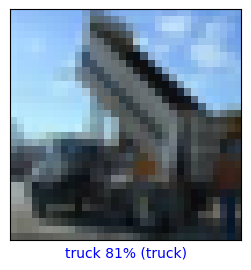

array([0.06190472, 0.01393062, 0.02579868, 0.00563415, 0.00415432,
       0.0031354 , 0.00082822, 0.01018702, 0.05985673, 0.8145701 ],
      dtype=float32)

In [135]:
i = 50
plt.figure(figsize=(6,3))
plot_image(i, predictions[i], test_labels[i], test_images[i])
plt.show()
predictions[i]

We see an image (in this case, an image of a 'truck').
Below the image, there's a text label formatted like truck 81% (truck). This means:
truck: The model's predicted class for this image.
81%: The confidence (probability) that the model assigns to its prediction for the 'truck' class.
(truck): The actual, true class of the image.
The color of this text label is crucial: if it's blue, the model's prediction is correct; if it were red, the prediction would be incorrect. In this instance, the prediction is correct, as 'truck' matches 'truck', and the label is blue.
The Raw Prediction Array:

array([0.06190472, 0.01393062, ..., 0.8145701 ], dtype=float32): This is the raw probability distribution generated by the model's final softmax layer for the displayed image. It's an array of 10 numbers, each corresponding to the probability that the image belongs to one of the 10 CIFAR-10 classes. The sum of these probabilities is approximately 1.
The np.argmax() function (used internally in plot_image and shown in Exercice 12) would find the index of the highest probability in this array. In this case, 0.8145701 is the highest probability, and its index corresponds to the 'truck' class, confirming the visual label.

# Homework Assignment: Deep Neural Network Classification with Fashion MNIST

Redo the classification part, this time utilizing the Fashion MNIST dataset and a DNN model with three Dense layers. The first and second Dense layers should have 128 neurons each. Additionally, incorporate the following specifications:

* Apply dropout after each hidden layer with a dropout rate of 0.25 (25% of neurons dropped randomly for the subsequent layer).
*  Set the batch size to 512.
*  Implement early stopping while fitting the model with a patience value of 20 and a maximum number of epochs set to 200.
*  Save the best model as 'model_best'.
*  Evaluate the saved model on the test data.

**For the submission of your work, please submit your completed assignment in HTML format.**



We load the Fashion MNIST dataset directly from Keras.

In [136]:
data = keras.datasets.fashion_mnist
fashion_data = data.load_data()

We check the type and size of `fashion_data`. This basic check ensures that the data loaded successfully before proceeding further.

In [137]:
type(fashion_data)
len(fashion_data)

2

We split the data into four categories: training images and labels, and test images and labels. This is the standard approach in deep learning: we train the model on the training set and evaluate its generalization on the test set, which consists of data the model has never seen before.



In [138]:
(train_images, train_labels), (test_images, test_labels) = fashion_data

We examine the first raw image: it is a 28×28 matrix of integer values ranging from 0 to 255. `np.unique(train_labels)` confirms that there are indeed 10 classes numbered from 0 to 9.

In [139]:
print(train_images[0])
print(train_images[0].shape)
np.unique(train_labels)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

We check the overall size of the dataset. We expect 60,000 training images (28, 28) and 10,000 test images.

In [140]:
print("train_images shape : ", train_images.shape)
print("train_labels size", len(train_labels))
print("train_labels", train_labels)
print("test_images shape : ", test_images.shape)
print("test_labels", test_labels)

train_images shape :  (60000, 28, 28)
train_labels size 60000
train_labels [9 0 0 ... 3 0 5]
test_images shape :  (10000, 28, 28)
test_labels [9 2 1 ... 8 1 5]


We display a single image to ensure that the data has loaded correctly and is readable. The `cmap='gray'` argument is important here: without it, matplotlib would apply a default color palette that would distort the grayscale representation of the image.

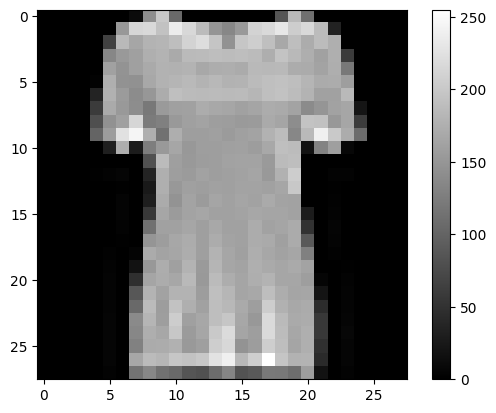

np.uint8(3)

In [141]:
index = 50
plt.figure()
plt.imshow(train_images[10], cmap='gray')
plt.colorbar()
plt.show()

train_labels[index]

A grid displaying the first 25 images and their corresponding classes is shown. This allows for a visual check of the consistency between the images and their labels. It is an essential quality control step before any training begins.

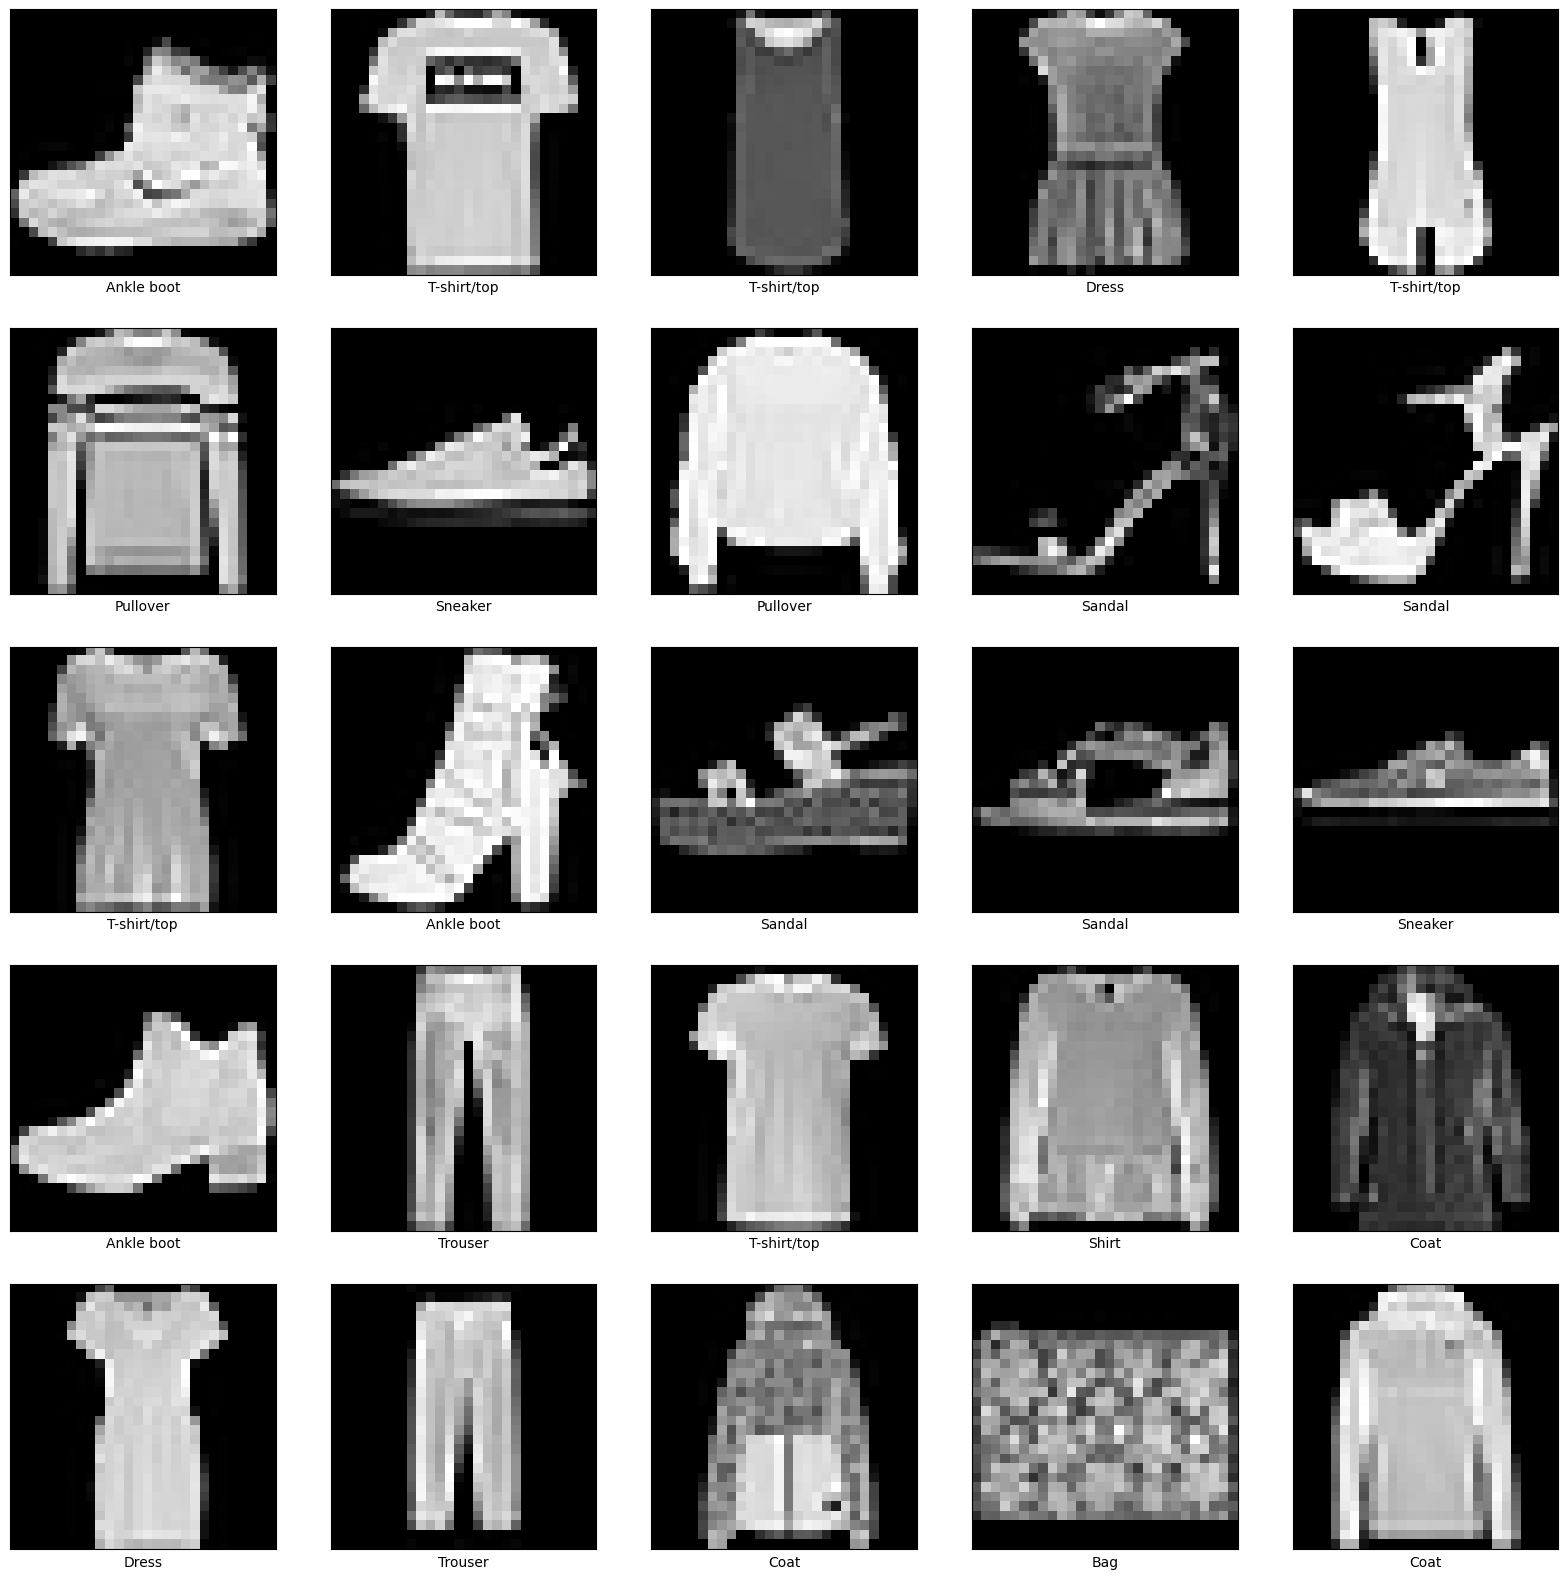

In [142]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(20,20))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap='gray')
    plt.xlabel(class_names[train_labels[i]])
plt.show()


Pixel values are normalized by dividing them by 255, which maps them to the range [0, 1]. This normalization is crucial: it accelerates the convergence of gradient descent, prevents vanishing and exploding gradient problems, and ensures that all features have the same input scale in the network.

In [143]:
train_images_before = train_images
test_images_before = test_images
train_images = train_images / 255.0
test_images = test_images / 255.0

We define the network architecture: using Flatten to transform the matrix
Dense, which creates the first hidden layer with 128 neurons and ReLU activation, introducing non-linearity
Dropout, which randomly deactivates 25% of the neurons at each training step to reduce overfitting.
Then we do the same for the second layer and the output layer

In [144]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


We configure and run the training using two callbacks: `EarlyStopping`, which stops training if `val_loss` does not improve for 20 consecutive epochs, and `ModelCheckpoint`, which automatically saves the best model instead of the latest one.


In [145]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model

es = EarlyStopping(monitor='val_loss', patience=20)
mc = ModelCheckpoint('model_best.keras', monitor='val_loss', save_best_only=True)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels,
                    epochs=200,
                    batch_size=512,
                    validation_split=0.1,
                    callbacks=[es, mc])

Epoch 1/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6866 - loss: 0.8829 - val_accuracy: 0.8148 - val_loss: 0.5071
Epoch 2/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8180 - loss: 0.5134 - val_accuracy: 0.8472 - val_loss: 0.4205
Epoch 3/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8413 - loss: 0.4463 - val_accuracy: 0.8563 - val_loss: 0.3909
Epoch 4/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8542 - loss: 0.4119 - val_accuracy: 0.8628 - val_loss: 0.3704
Epoch 5/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8605 - loss: 0.3906 - val_accuracy: 0.8703 - val_loss: 0.3519
Epoch 6/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8661 - loss: 0.3715 - val_accuracy: 0.8753 - val_loss: 0.3387
Epoch 7/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8704 - loss: 0.3621 - val_accuracy: 0.8795 - val_loss: 0.3415
Epoch 8/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8769 - loss: 0.3439 - val

We load the best saved model and evaluate it on the test set using ModelCheckpoint, retrieving the model at the optimal generalization point, before it starts to overfit. The resulting test_accuracy is our measure of actual performance on unseen data.

In [146]:
saved_model = load_model('model_best.keras')
test_loss, test_acc = saved_model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8866 - loss: 0.3179

Test accuracy: 0.8866000175476074


We generate the model's predictions for all test images. For the image at index 10, we return a vector of 10 probabilities. np.argmax() selects the index of the highest probability, which corresponds to the predicted class. We then compare this with test_labels[10] to verify whether the prediction is correct.

In [147]:
predictions = saved_model.predict(test_images)
predictions[10]
np.argmax(predictions[10])
test_labels[10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


np.uint8(4)

 We visualize the prediction results for a given image. The `plot_image` function displays the image with a legend showing the predicted class, its confidence score, and the true class. The label appears in blue if the prediction is correct, and in red otherwise. This visualization allows us to qualitatively analyze the model’s errors and understand which categories are being misclassified.

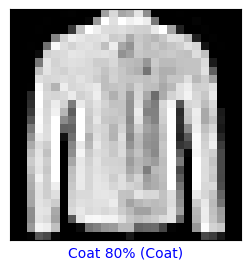

array([6.7335539e-05, 1.9198956e-09, 6.4736083e-02, 1.5347986e-06,
       7.9873693e-01, 4.2032062e-09, 1.3645621e-01, 2.0079327e-11,
       1.9497716e-06, 2.4206773e-10], dtype=float32)

In [148]:
def plot_image(i, predictions_array, true_label, img):
    true_label = true_label
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap='gray')
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

i = 50
plt.figure(figsize=(6,3))
plot_image(i, predictions[i], test_labels[i], test_images[i])
plt.show()
predictions[i]

# Converting a notebook to html

In [149]:
from google.colab import drive
drive.mount('/content/gdrive')
#%%shell
!jupyter nbconvert --to html '/content/gdrive/MyDrive/Colab Notebooks/DL_Lab1_NN.ipynb'

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
[NbConvertApp] Converting notebook /content/gdrive/MyDrive/Colab Notebooks/DL_Lab1_NN.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 971404 bytes to /content/gdrive/MyDrive/Colab Notebooks/DL_Lab1_NN.html
